# Cell 1: Import Library

In [1]:
# Cell 1: Import dependencies

# Import all library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import specific tool
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# Visualitation setup
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Cell 2: Load Data and Basic Feature Engineering

In [2]:
# Cell 2: Data Loading & Basic Feature Engineering

print ("Loading data...")
df = pd.read_csv('Dataset/application_train.csv') 

# EXPLORATION: Display statistics for the original column to demonstrate the presence of the 365243 anomaly.
print("=== INITIAL DAYS_EMPLOYED STATISTIC ===")
print(df['DAYS_EMPLOYED'].describe())
print("===================================\n")

# Replace anomaly 365243 with NaN before calculation.
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

# Convert age and length of service from days (negative) to years (positive)
df['DAYS_BIRTH_YEARS'] = df['DAYS_BIRTH'] / -365
df['DAYS_EMPLOYED_YEARS'] = df['DAYS_EMPLOYED'] / -365

# Viewing the statistical description of the DAYS_EMPLOYED_YEARS column
print("=== CORRECTED DAYS_EMPLOYED_YEARS STATISTIC ===")
print(df['DAYS_EMPLOYED_YEARS'].describe())

# Drop the original column to avoid linear multicollinearity.
df.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)

print(f"dataset shape: {df.shape}")
print(f"Target distribution:\n{df['TARGET'].value_counts(normalize=True)}")

Loading data...
=== INITIAL DAYS_EMPLOYED STATISTIC ===
count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

=== CORRECTED DAYS_EMPLOYED_YEARS STATISTIC ===
count    252137.000000
mean          6.531971
std           6.406466
min          -0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: DAYS_EMPLOYED_YEARS, dtype: float64
dataset shape: (307511, 122)
Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


# Cell 3: Relational Feature Engineering

In [3]:
# Cell 3: Relational Feature Engineering

print("Processing historical data from supporting tables...")

# 1. Feature Extraction from the Credit Bureau (Loan history at other banks)
try:
    bureau = pd.read_csv('Dataset/bureau.csv')
    # Calculate the number of loans and loan amount statistics.
    bureau_agg = bureau.groupby('SK_ID_CURR').agg({
        'SK_ID_BUREAU': 'count',
        'DAYS_CREDIT': ['min', 'max', 'mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum']
    })
    # Clean up column names from multi-index aggregation.
    bureau_agg.columns = ['BUREAU_' + '_'.join(col).strip().upper() for col in bureau_agg.columns.values]
    
    # Merge into the main dataframe.
    df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
    print("Successfully combined bureau.csv")
except FileNotFoundError:
    print("bureau.csv not found, skipping this step.")

# 2. Feature extraction from previous applications (prior application history with Home Credit)
try:
    prev_app = pd.read_csv('Dataset/previous_application.csv')
    prev_agg = prev_app.groupby('SK_ID_CURR').agg({
        'SK_ID_PREV': 'count',
        'AMT_CREDIT': ['min', 'max', 'mean'],
        'AMT_ANNUITY': ['max', 'mean']
    })
    prev_agg.columns = ['PREV_' + '_'.join(col).strip().upper() for col in prev_agg.columns.values]
    
    df = df.merge(prev_agg, on='SK_ID_CURR', how='left')
    print("Successfully combined previous_application.csv")
except FileNotFoundError:
    print("previous_application.csv not found, skipping this step.")

print(f"Final form of the dataset before entering the pipeline: {df.shape}")

Processing historical data from supporting tables...
Successfully combined bureau.csv
Successfully combined previous_application.csv
Final form of the dataset before entering the pipeline: (307511, 135)


# Cell 4: Enterprise-Grade Data Preprocessing Pipeline

In [4]:
# Cell 4: Splitting and Preprocessing Architecture.

# Devide feature and target.
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# Column type identification.
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Pipeline for numerical data: Fill missing values with the median, then scale.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# # Pipeline for categorical data: Fill missing values with the mode, then One-Hot Encode.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Train-Test Split (stratify to maintain the imbalanced target ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data splitted successfully.")

Data splitted successfully.


# Cell 5: Model 1 - Logistic Regression (Baseline)

In [5]:
# Cell 5: Logistic Regression Pipeline

print("Training Logistic Regression...")
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

# Probability prediction
y_pred_proba_lr = logreg_pipeline.predict_proba(X_test)[:, 1]
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"Logistic Regression ROC-AUC Score: {roc_auc_lr:.4f}")

# Discrete class prediction & Classification Report
y_pred_lr = logreg_pipeline.predict(X_test)
print("\nClassification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Training Logistic Regression...
Logistic Regression ROC-AUC Score: 0.7510

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.96      0.69      0.81     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.69      0.53     61503
weighted avg       0.90      0.69      0.76     61503



# Cell 6: Model 2 - Random Forest (Advanced Model)

In [6]:
# Cell 6: Random Forest Pipeline

print("Training Random Forest...")
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest ROC-AUC Score: {roc_auc_rf:.4f}")

# Discrete class prediction & Classification Report
y_pred_rf = rf_pipeline.predict(X_test)
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

Training Random Forest...
Random Forest ROC-AUC Score: 0.7352

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.74      0.83     56538
           1       0.17      0.60      0.26      4965

    accuracy                           0.73     61503
   macro avg       0.56      0.67      0.55     61503
weighted avg       0.89      0.73      0.79     61503



# Cell 7: Evaluation & ROC-AUC Curve

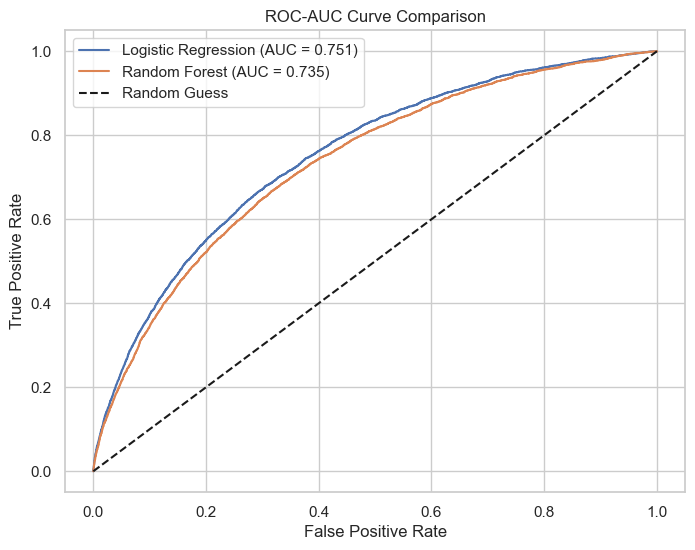

In [7]:
# Cell 7: ROC-AUC Visualization

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend()
plt.show()

# Cell 8: Feature Importance Extraction

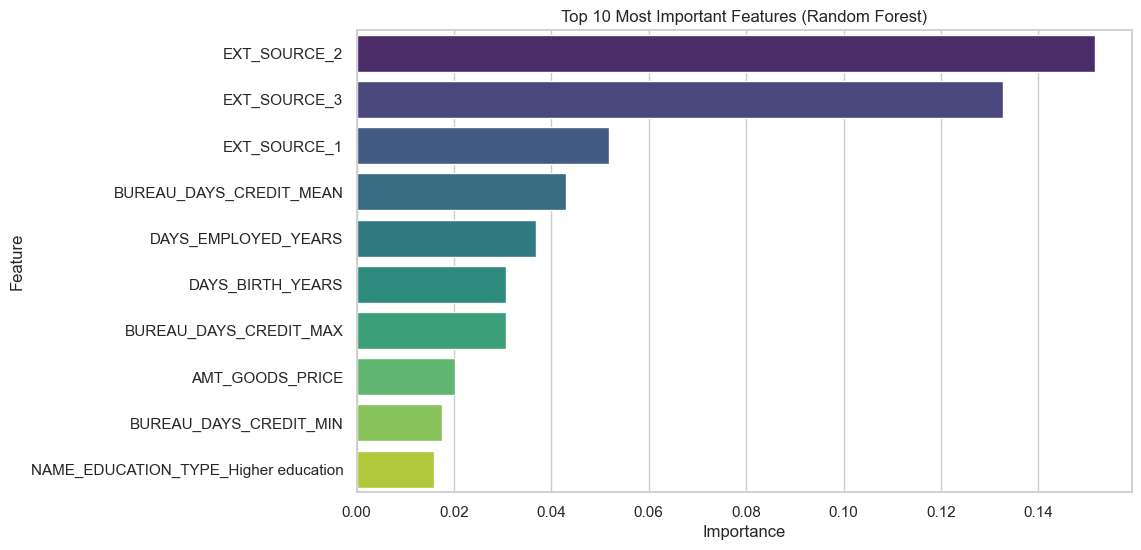

In [8]:
# Cell 8: Extracting Feature Importance from Random Forest

# Get the names of the numerical features.
numeric_feature_names = numeric_features.tolist()

# Get the names of the categorical features after encoding (Using named_transformers_ to make it more robust and not dependant to index array)
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
categorical_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
# Combine all feature names.
all_feature_names = numeric_feature_names + categorical_feature_names

# Retrieve the feature importance values from the Random Forest model.
rf_model = rf_pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

# Create a dataframe and sort it.
feature_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.show()